In [95]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
def forward_eulers(func, t_start, t_stop, step, f_init, u_th, u_rest, amp):
    # initialize
    num_steps = int((t_stop - t_start) / step)
    t_vals = np.linspace(t_start, t_stop, num_steps+1)
    f_vals = np.empty(len(t_vals))
    f_vals[0] = f_init
    
    for idx in range(1,len(t_vals)):
        f_cur = f_vals[idx - 1]
        t_cur = t_vals[idx - 1]
        # if f_cur > u_th:
            # f_vals[idx] = u_rest
        #else:
        f_vals[idx] = f_cur + step*func(t_cur, f_cur, amp)

    return t_vals, f_vals

In [129]:
def lif(t, u, R, tau_m, tau_s, I_0, u_rest = 0):   
    I = I_0 * np.e**(-t/tau_s)

    du_dt = (-(u - u_rest) + R*I)/tau_m
    return du_dt

In [131]:
def lif_simple(t, u, amp):
    return lif(t, u, R = 1, tau_m = 10, tau_s = 2, I_0 = amp, u_rest = 0)

In [143]:
t_lif12, f_lif12 = forward_eulers(lif_simple, t_start = 0, t_stop = 50, step = .01, f_init = 0, u_th = 1, u_rest = 0, amp = 12)
t_lif8, f_lif8 = forward_eulers(lif_simple, t_start = 0, t_stop = 50, step = .01, f_init = 0, u_th = 1, u_rest = 0, amp = 1/5**-1.25)
t_lif4, f_lif4 = forward_eulers(lif_simple, t_start = 0, t_stop = 50, step = .01, f_init = 0, u_th = 1, u_rest = 0, amp = 4)


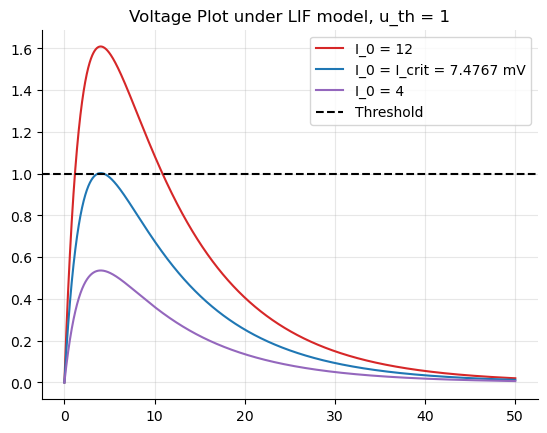

In [167]:
plt.plot(t_lif12, f_lif12, 
         color="#d62728", label = "I_0 = 12")
plt.plot(t_lif8, f_lif8, 
         color="#1f77b4", label = "I_0 = I_crit = 7.4767 mV")
plt.plot(t_lif4, f_lif4, 
         color = "#9467bd", label = "I_0 = 4")
plt.axhline(y = 1, color = "black", linestyle = "--", label = "Threshold")

plt.legend()
plt.title("Voltage Plot under LIF model, u_th = 1")
plt.grid(alpha = .3)
sns.despine()

plt.savefig("hw1p4_voltage.png")
plt.show()

In [147]:
print("Max voltage at 12, I_crit and 4 mV:", max(f_lif12), max(f_lif8), max(f_lif4))

Max voltage at 12, I_crit and 4 mV: 1.609594198170309 1.0028769677061338 0.536531399390103


Now time to plot the other part of this problem

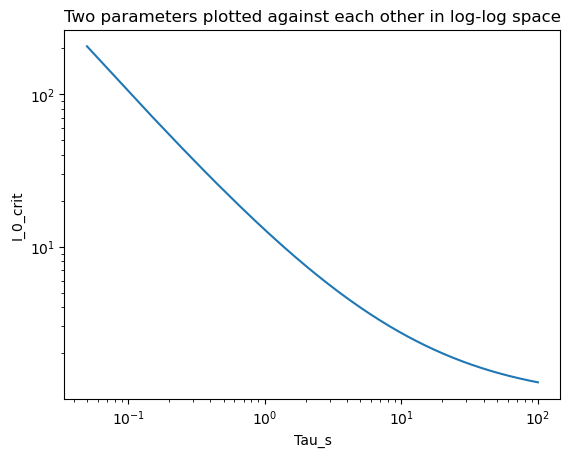

In [165]:
tau_s = np.linspace(.05,100, 1000)
i_crit = (tau_s/10)**(1/(tau_s/10 - 1))

plt.loglog(tau_s, i_crit)
plt.xlabel("Tau_s")
plt.ylabel("I_0_crit")
plt.title("Two parameters plotted against each other in log-log space")

plt.savefig("hw1p4_fig.png")
plt.show()